In [54]:
import os
import pandas as pd
import re
def load_all_tests(type_folder, # Jadikan ini argumen wajib atau opsional
                   base_dir='../hasil_eksperimenV12_parity',
                   rel_path=('vqe_execution', 'vqe_results_multi_bond_length.csv')):
    
    # Gabungkan base_dir dengan type_folder
    full_base_path = os.path.join(base_dir, type_folder)
    
    # Fungsi pembantu untuk natural sorting
    def natural_key(text):
        return [int(c) if c.isdigit() else c for c in re.split(r'(\d+)', text)]

    dataframes = []
    
    # Pastikan folder ada sebelum listdir
    if not os.path.exists(full_base_path):
        raise FileNotFoundError(f"Folder tidak ditemukan: {full_base_path}")

    dir_list = sorted(os.listdir(full_base_path), key=natural_key)

    for test_dir in dir_list:
        csv_path = os.path.join(full_base_path, test_dir, *rel_path)
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df['model'] = test_dir
            dataframes.append(df)
            
    if not dataframes:
        raise FileNotFoundError(f"Tidak ada file di {full_base_path}")

    full_df = pd.concat(dataframes, ignore_index=True)
    
    # Tetap gunakan categorical agar urutan J-S-1, J-S-2 dst tetap terjaga
    full_df['model'] = pd.Categorical(full_df['model'], categories=dir_list, ordered=True)
    
    return full_df

In [55]:
import numpy as np

df = load_all_tests('single')
# 1. Hitung squared error untuk Mitigated Energy
df['sq_error_mitigated'] = (df['mitigated_energy'] - df['ideal_energy'])**2

# 2. Hitung squared error untuk Noisy Energydf
df['sq_error_noisy'] = (df['noisy_energy'] - df['ideal_energy'])**2

# 3. Groupby per model dan hitung L_2
l2_comparison = (
    df.groupby(['model'], observed=True)[['sq_error_mitigated', 'sq_error_noisy']]
      .sum()
      .reset_index()
)

l2_comparison['l2_mitigated'] = np.sqrt(l2_comparison['sq_error_mitigated'])
l2_comparison['l2_noisy'] = np.sqrt(l2_comparison['sq_error_noisy'])

# 4. Urutkan berdasarkan L2 mitigated
l2_comparison_sorted = (
    l2_comparison
    .sort_values(by='l2_mitigated')
    .head(3)
)

print(l2_comparison_sorted[['model', 'l2_mitigated', 'l2_noisy']])

   model  l2_mitigated  l2_noisy
1  P-S-2        0.0196    0.1116
4  P-S-5        0.0225    0.0993
2  P-S-3        0.0286    0.0953


In [56]:
top_models_list = l2_comparison_sorted['model'].to_list()

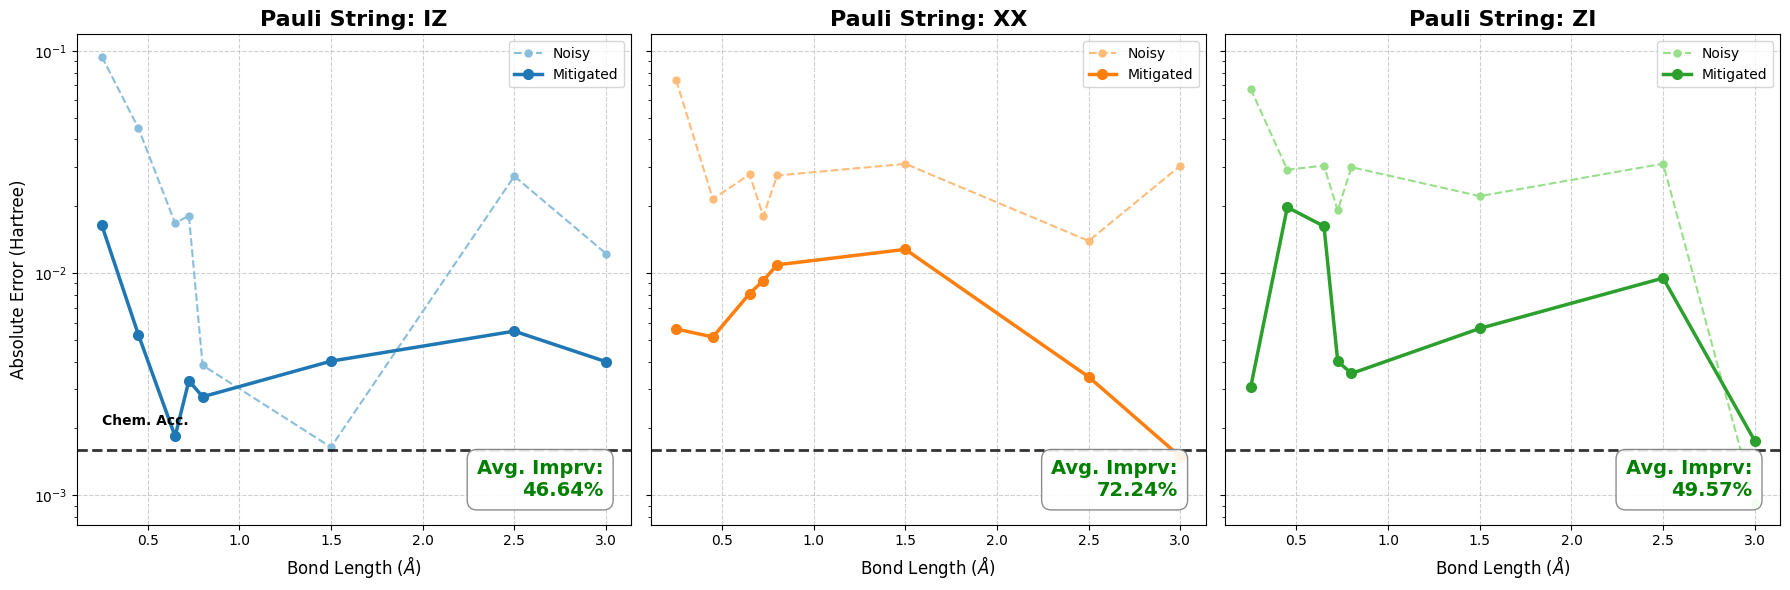

In [57]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

# --- 0. MAPPING DICTIONARY ---
# pauli_map_data = {
#     '1': 'IIII',  '2': 'IIIZ',  '3': 'IIZI',  '4': 'IIZZ',
#     '5': 'IZII',  '6': 'IZIZ',  '7': 'ZIII',  '8': 'ZIIZ',
#     '9': 'YYYY',  '10': 'XXYY', '11': 'YYXX', '12': 'XXXX',
#     '13': 'IZZI', '14': 'ZIZI', '15': 'ZZII'
# }
pauli_map_data = {
    '2': 'IZ',  '3': 'ZI',  '4': 'ZZ',
    '5': 'XX' }

# --- 1. SETUP DATA ---
col_ideal = 'total_ideal_energy' if 'total_ideal_energy' in df.columns else 'ideal_energy'
col_noisy = 'total_noisy_energy' if 'total_noisy_energy' in df.columns else 'noisy_energy'
col_mitigated = 'total_mitigated_energy' if 'total_mitigated_energy' in df.columns else 'mitigated_energy'

# Hitung Absolute Error
df['abs_err_noisy'] = (df[col_noisy] - df[col_ideal]).abs()
df['abs_err_mitigated'] = (df[col_mitigated] - df[col_ideal]).abs()

# Hitung Improvement (%)
df['Improvement_Pct'] = (
    (df['abs_err_noisy'] - df['abs_err_mitigated']) / 
    df['abs_err_noisy']
) * 100

# --- 2. KONFIGURASI ---
target_models = top_models_list 

color_themes = [
    {'main': '#1f77b4', 'light': "#89bedc"}, 
    {'main': '#ff7f0e', 'light': '#ffbb78'}, 
    {'main': '#2ca02c', 'light': '#98df8a'}  
]

# --- 3. PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)
if len(target_models) == 1: axes = [axes]

for i, model_name in enumerate(target_models):
    if i >= 3: break 
    ax = axes[i]
    style = color_themes[i]
    
    # Filter Data
    subset = df[df['model'] == model_name].sort_values(by='bond_length')
    
    if subset.empty:
        ax.set_title(f"{model_name} (No Data)")
        continue
        
    X_data = subset['bond_length']

    # Plot Lines
    ax.plot(X_data, subset['abs_err_noisy'], 
            color=style['light'], marker='o', markersize=5, 
            linestyle='--', linewidth=1.5, label='Noisy')

    ax.plot(X_data, subset['abs_err_mitigated'], 
            color=style['main'], marker='o', markersize=7, 
            linestyle='-', linewidth=2.5, label='Mitigated')

    # --- TEXT IMPROVEMENT (KANAN BAWAH) ---
    avg_imp = subset['Improvement_Pct'].mean()
    text_color = 'green' if avg_imp > 0 else 'red'
    info_text = f"Avg. Imprv:\n{avg_imp:.2f}%"
    
    # Koordinat (0.95, 0.05) = Kanan Bawah
    # ha='right' penting agar teks tumbuh ke kiri dan tidak keluar frame
    ax.text(0.95, 0.05, info_text, 
            transform=ax.transAxes, 
            fontsize=14, fontweight='bold', color=text_color,
            ha='right', va='bottom',  # <-- Alignment Kanan Bawah
            bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9, edgecolor='gray'))

    # --- FORMATTING ---
    ax.set_yscale('log')
    
    # Mapping Judul
    match = re.search(r'S-(\d+)', str(model_name))
    if match:
        pauli_string = pauli_map_data.get(match.group(1), model_name)
        title_text = f"Pauli String: {pauli_string}"
    else:
        title_text = str(model_name).replace('_', ' ').title()

    ax.set_title(title_text, fontsize=16, fontweight='bold')
    ax.set_xlabel(r"Bond Length ($\AA$)", fontsize=12)
    ax.grid(True, which='major', linestyle='--', alpha=0.6)
    
    # Chemical Accuracy Line
    chem_acc = 0.0016
    ax.axhline(y=chem_acc, color='black', linestyle='--', linewidth=2, alpha=0.8)
    
    if i == 0:
        ax.set_ylabel("Absolute Error (Hartree)", fontsize=12)
        ax.text(X_data.min(), chem_acc * 1.3, 'Chem. Acc.', fontsize=10, fontweight='bold')
    
    # Legend ditaruh di Kiri Bawah atau Kanan Atas agar tidak menabrak teks
    ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()


In [37]:
# --- 2. MENGHITUNG L2 (RMSE) PER MODEL ---
# Group by 'model' (bukan experiment_type)
df_model_l2 = df.groupby('model', observed=True)[['sq_error_noisy', 'sq_error_mitigated']].sum().reset_index()

# Akar Kuadratkan (Sqrt) untuk mendapatkan L2 / RMSE
df_model_l2['l2_noisy'] = np.sqrt(df_model_l2['sq_error_noisy'])
df_model_l2['l2_mitigated'] = np.sqrt(df_model_l2['sq_error_mitigated'])

# --- 3. FORMATTING TABEL ---
# Menghitung Persentase Perbaikan
df_model_l2['Improvement (%)'] = (
    (df_model_l2['l2_noisy'] - df_model_l2['l2_mitigated']) / 
    df_model_l2['l2_noisy']
) * 100

# Opsional: Merapikan nama model (misal ganti '_' jadi spasi)
df_model_l2['model'] = df_model_l2['model'].astype(str).str.replace('_', ' ').str.title()

# Merapikan Kolom
df_final_model = df_model_l2[['model', 'l2_noisy', 'l2_mitigated', 'Improvement (%)']].copy()
df_final_model.columns = [
    'Model Name', 
    'L2 Noisy (Ha)', 
    'L2 Mitigated (Ha)', 
    'Improvement (%)'
]

# --- 4. URUTKAN DARI YANG TERBAIK ---
# Mengurutkan berdasarkan L2 Mitigated terendah (error paling kecil)
df_final_model = df_final_model.sort_values(by='L2 Mitigated (Ha)', ascending=True).reset_index(drop=True)

# --- 5. MENAMPILKAN HASIL ---
print("\n" + "="*20 + " MODEL PERFORMANCE: L2 (RMSE) " + "="*20)
pd.options.display.float_format = '{:,.4f}'.format

df_final_model


==================== MODEL PERFORMANCE: L2 (RMSE) ====================


,Model Name,L2 Noisy (Ha),L2 Mitigated (Ha),Improvement (%)
0,P-S-2,0.1116,0.0196,82.4686
1,P-S-5,0.0993,0.0225,77.3439
2,P-S-3,0.0953,0.0286,69.9523
3,P-S-4,0.0937,0.0436,53.4006
4,P-S-1,0.1114,3.0819,"-2,666.6991"
